In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("HR_Attrition.csv")

In [21]:
df.head()
df.info()
df.shape
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 11 columns):
 #   Column              Dtype         
---  ------              -----         
 0   Employee_ID         object        
 1   Full_Name           object        
 2   Department          object        
 3   Job_Title           object        
 4   Hire_Date           datetime64[ns]
 5   Location            object        
 6   Performance_Rating  int64         
 7   Experience_Years    int64         
 8   Status              object        
 9   Work_Mode           object        
 10  Salary_INR          int64         
dtypes: datetime64[ns](1), int64(3), object(7)
memory usage: 167.8+ MB


,Hire_Date,Performance_Rating,Experience_Years,Salary_INR
count,2000000,2.000000e+06,2.000000e+06,2.000000e+06
mean,2020-02-11 07:02:40.689599488,3.000148e+00,5.010287e+00,8.968878e+05
min,2010-08-14 00:00:00,1.000000e+00,0.000000e+00,3.000000e+05
25%,2017-06-27 00:00:00,2.000000e+00,2.000000e+00,6.163460e+05
50%,2020-08-12 00:00:00,3.000000e+00,5.000000e+00,8.110265e+05
75%,2023-02-09 00:00:00,4.000000e+00,8.000000e+00,1.073745e+06
max,2025-08-13 00:00:00,5.000000e+00,1.500000e+01,2.999976e+06
std,NaN,1.413973e+00,3.608823e+00,4.026103e+05


In [20]:
df["Employee_ID"].nunique()

2000000

In [13]:
df["Hire_Date"] = pd.to_datetime(df["Hire_Date"])

In [7]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [8]:
df.isnull().sum()

Employee_ID           0
Full_Name             0
Department            0
Job_Title             0
Hire_Date             0
Location              0
Performance_Rating    0
Experience_Years      0
Status                0
Work_Mode             0
Salary_INR            0
dtype: int64

In [ ]:
df.duplicated().sum()


np.int64(0)

In [10]:

df["Department"].value_counts()

Department
IT            601042
Sales         400031
Operations    300095
Marketing     240081
Finance       199873
HR            159119
R&D            99759
Name: count, dtype: int64

In [11]:
df["Status"].value_counts()

Status
Active        1401558
Resigned       398660
Retired         99912
Terminated      99870
Name: count, dtype: int64

In [12]:
df["Work_Mode"].value_counts()

Work_Mode
On-site    1199109
Remote      800891
Name: count, dtype: int64

In [23]:
df.groupby("Department")["Salary_INR"].mean().sort_values(ascending=False)

Department
IT            1.129858e+06
Finance       9.404117e+05
R&D           8.003772e+05
Sales         7.929579e+05
Marketing     7.699362e+05
Operations    7.546263e+05
HR            7.438536e+05
Name: Salary_INR, dtype: float64

In [24]:
df.groupby("Work_Mode")["Salary_INR"].mean()

Work_Mode
On-site    896835.945792
Remote     896965.326373
Name: Salary_INR, dtype: float64

In [25]:
df.groupby("Performance_Rating")["Salary_INR"].mean()

Performance_Rating
1    897349.444173
2    896712.984404
3    896273.208980
4    897389.988453
5    896712.440343
Name: Salary_INR, dtype: float64

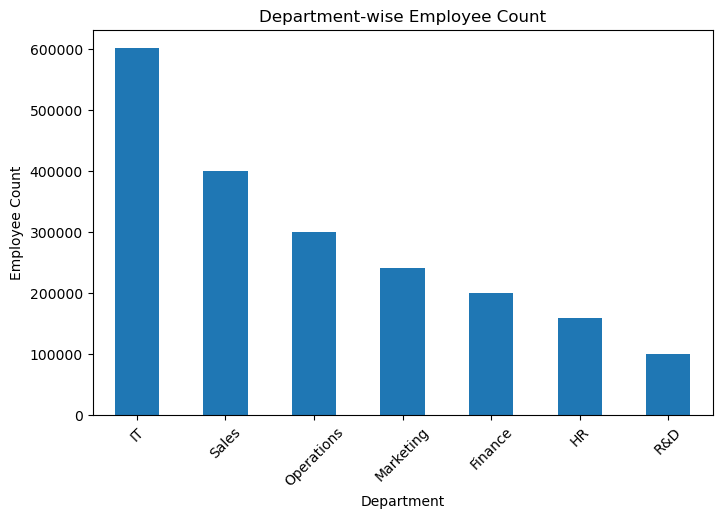

In [39]:
import matplotlib.pyplot as plt

df["Department"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Department-wise Employee Count")
plt.xlabel("Department")
plt.ylabel("Employee Count")
plt.xticks(rotation=45)
plt.show()

Insights:-

• The IT department has the highest number of employees.

• The R&D(Research & Development) department has the lowest employee count.

• This indicates that the organization is primarily focused on technical roles.

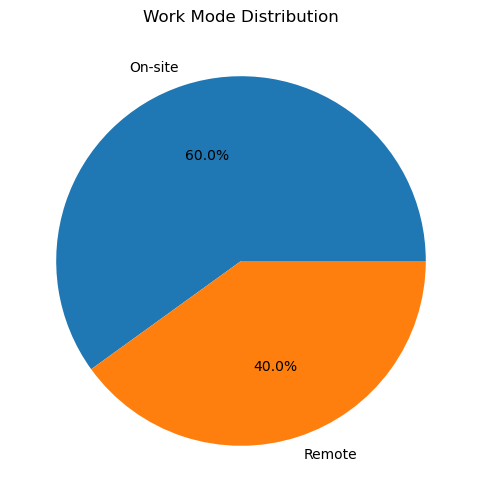

In [30]:
df["Work_Mode"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)
plt.title("Work Mode Distribution")
plt.ylabel("")
plt.show()

Insights:-

• 60% of employees work from the Office, making it the dominant work mode.

• 40% of employees work Remotely, indicating that the company also supports flexible work arrangements.

• The organization primarily follows an office-based work model while offering remote work opportunities.

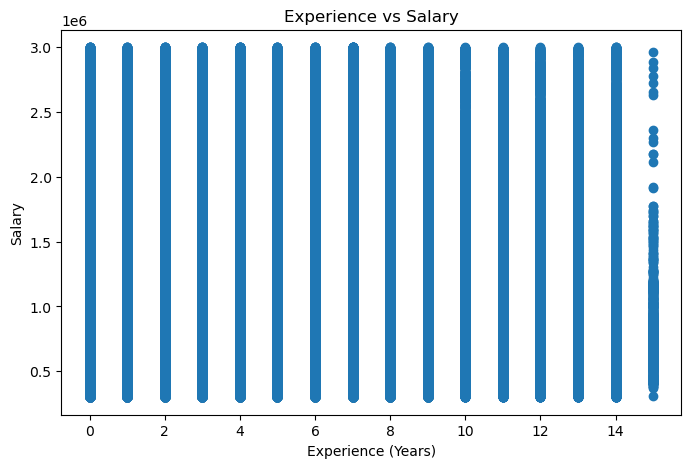

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["Experience_Years"], df["Salary_INR"])
plt.title("Experience vs Salary")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")
plt.show()

Insights:-

• Employees across all experience levels have a wide range of salaries.

• There is no strong linear relationship between experience and salary in the dataset.

• Factors other than experience, such as job role, department, or performance, may also influence employee salaries.

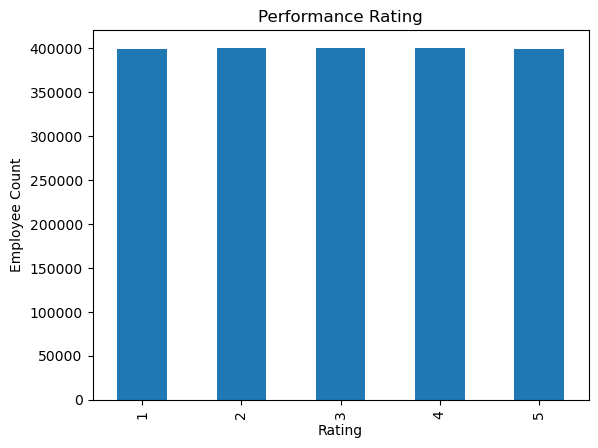

In [33]:
df["Performance_Rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Performance Rating")
plt.xlabel("Rating")
plt.ylabel("Employee Count")
plt.show()

Insights:-

• Employees are almost equally distributed across ratings 1 to 5.

• No performance rating has significantly more or fewer employees than the others.

• The performance ratings appear to be balanced throughout the organization.

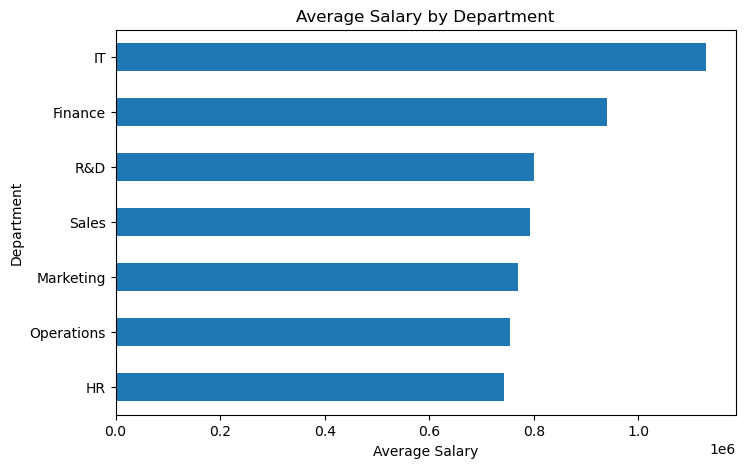

In [34]:
avg_salary = df.groupby("Department")["Salary_INR"].mean().sort_values()

avg_salary.plot(kind="barh", figsize=(8,5))
plt.title("Average Salary by Department")
plt.xlabel("Average Salary")
plt.show()

Insights:-

• The IT department offers the highest average salary, suggesting a greater demand for technical expertise and specialized skills.

• Finance and R&D also provide competitive average salaries compared to other departments.

• HR, Operations, and Marketing have relatively lower average salaries, highlighting variations in compensation across departments.

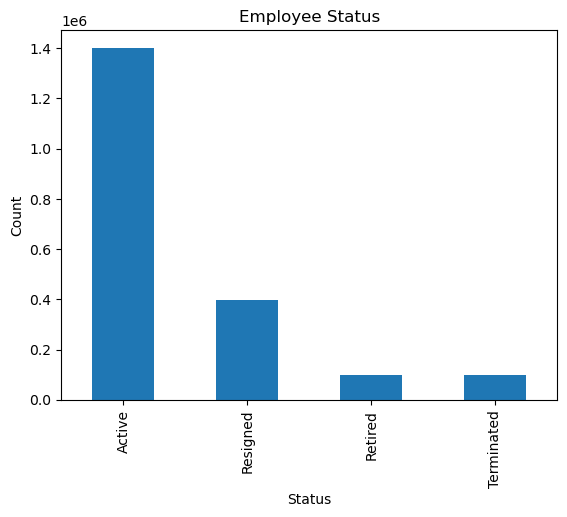

In [35]:
df["Status"].value_counts().plot(kind="bar")
plt.title("Employee Status")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

Insights:-

• The majority of employees are currently Active, indicating a stable workforce.

• Resigned employees represent the second-largest group, suggesting a moderate level of employee turnover.

• Retired and Terminated employees make up only a small portion of the workforce

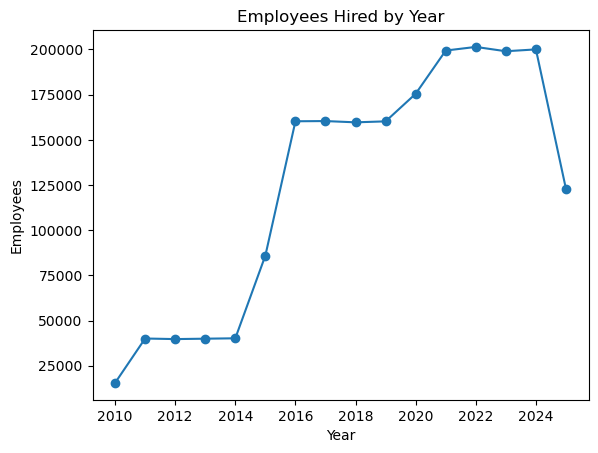

In [36]:
df["Hire_Year"] = df["Hire_Date"].dt.year

df["Hire_Year"].value_counts().sort_index().plot(kind="line", marker="o")
plt.title("Employees Hired by Year")
plt.xlabel("Year")
plt.ylabel("Employees")
plt.show()

Insights:-

• Employee hiring increased steadily from 2010 to 2022, indicating continuous organizational growth.

• The highest number of employees were hired between 2021 and 2024, reflecting a strong recruitment phase.

• Hiring declined significantly in 2025 compared to previous years.

Conclusion:-

• The dataset was cleaned by removing unnecessary columns and verifying data quality.

• The IT department has the highest average salary, while HR has the lowest.

• Most employees work from the Office, indicating an office-based work culture.

• Employee salaries are concentrated in the mid-salary range, with fewer employees earning very high salaries.

• Performance ratings are evenly distributed across all employees.

• Hiring increased significantly after 2015, with the highest recruitment observed between 2021 and 2024.

• The majority of employees are currently Active, indicating a stable workforce.